# 1. Chrome-Dino Game Overview: 🦖 🦕

It is a classical game that was developed by Sebastien Gabriel, Alan Bettes, and Edward Jung in 2014, it was initally developed as an Easter game by Google

![Dino Game](Images//dino_game_demo.png)

the goal of this game is to navigate through the obstacles 🌵 and survive for the longest period possible, the longer you are alive the faster the game gets

**Our Goals**
-   Train an AI Agent that interacts with the environment of the game, navigate through the obstacles and achieve a good reasonable score `10,000` points
- Intrepret decisions taken by the AI Agent using `(XRL)` Explainable Reinforcement Learning techniques helps us understand why did the agent take that specific action in that given state
- Compare and Contrast Different Reinforcement Learning Techniques

# 2. Setting Up Environment for Reinforcement Learning 🏜️

The hardest part of our problem is to get the custom environment set up so we can train one of the reinforcement learning models to play the game, we can do this via opening chrome then using `pyautogui` or `pynput` which would allow us to control the agent movement such as `Jumping`, `Ducking`, `No Operation`, Technically we can use `pyautogui` to take screenshots of the game and they would be the state/observation fed to the AI Agent, However `pyautogui` is considered slow, instead to speed up the process we will use `pynput` and `MSS` libraries, `pynput` would be used for low-level and `MSS` is a light library that runs fast and takes screenshots quickly, then after awards we will use OpenAI `Gymnasium` to build our custom environment, so we can use standard functions such as `reset()`, `step()` , `render()`.

**Workflow**

1. Open Chrome Automatically
2. Build `ChromeDinoController` class, it allow AI agents to interact with chrome, and take screenshots rapidly
2. Wrapping Environment as a custom Environment in OpenAI `Gymnasium`

*Note: to ensure that ChromeDinoController works only if chrome is up and webpage is dino, we will use `pywinctl` library to check current opened application*

In [5]:
import pywinctl
import mss
import time
from pynput.keyboard import Controller, Key
import numpy as np
import matplotlib.pyplot as plt
# from paddleocr import TextRecognition
import cv2
import easyocr
import subprocess
from subprocess import DEVNULL, STDOUT


class DinoController:
    def __init__(self,monitor, game_over_monitor):
        self.keyboard = Controller()
        self.monitor = monitor
        self.reader = easyocr.Reader(["en"])
        self.game_over_monitor = game_over_monitor
        self._init_game()
        self.previous_key = None
        self.score = 1

    def _launch_chrome(self):
        """
        It launches chrome incognito mode for us

        Note if we use run() instead Popen() we would not be able to move on or execute other scripts unless chrome is closed
        Note to avoid [WinError 2] The system cannot find the file specified error make sure to set shell=True
        """

        try:
            subprocess.Popen(["start","chrome","--incognito"], stdout=DEVNULL, stderr=DEVNULL, shell=True)
            print("Chrome has succesfully opened")
        except Exception as e:
            print("Error occurred while trying to launch Chrome :=> ",e)    
            return False

        return True

    def _search_game(self):
        """
        selects address bar then types game URL then presses enter
        """

        self.keyboard.press(Key.ctrl_l)
        self.keyboard.release(Key.ctrl_l)
        self.keyboard.type(GAME_URL)
        self.keyboard.press(Key.enter)
        self.keyboard.release(Key.enter)

    def _init_game(self):
        """
        prepares dino game for us
        """
        print("inside _init_game()")

        if self._launch_chrome():
            time.sleep(1)
            self._search_game()
        else:
            print("Error in _init_game() chrome cannot start")


    def ExecuteAction(self, key):
        """
        It takes a key, and executes it using `pynput` 
        """
        if key != self.previous_key:
            if self.previous_key is not None:
                self.keyboard.release(self.previous_key)
            self.keyboard.press(key)
        else:
            self.keyboard.press(key)

        self.previous_key = key

    def TakeScreenShot(self):
        """
        It takes a screenshot using light library `MSS` 
        """
        
        with mss.mss() as sct:
            state_image = np.array(sct.grab(self.monitor))[:,:,:3] #discard alpha channel

            return state_image

    def IsGameOn(self):
        """
        using `pywinctl` it checks if game is focused or not
        returns boolean

        this is useful for other function such as `ExecuteAction()` and `TakeScreenShot()` to avoid firing them
        if game is not focused
        """
        return pywinctl.getWindowsWithTitle("chrome://dino/ - Dino game, press space to play")

    def IsGameOver(self):
        """
        using `easyocr` which is a built-machine learning library for character recognition to check
        if game is over or not
        """
        with mss.mss() as sct:
            game_over_image = np.array(sct.grab(self.game_over_monitor))

        img = cv2.resize(cv2.cvtColor(game_over_image,cv2.COLOR_RGB2GRAY),dsize=(30,50))
        results = self.reader.readtext(image=img)
        return len(results)!=0
    
    def IncreaseScore(self):
        self.score+=1
    
    def GetScore(self):
        return self.score

    def Restart(self):
        self.keyboard.press(Key.f5)
        self.keyboard.release(Key.f5)

        
GAME_URL="chrome://dino"
monitor = {"top":110,"left":600,"width":700,"height":300}
game_over_monitor = {"top":200,"left":800,"width":200,"height":50}

In [6]:
import gymnasium as gym
from typing import Optional
from enum import Enum

class Actions(Enum):
    """
    a library used for increasing readability of code
    instead of putting:
        0:Key.Space
    we use:
        JUMP.value:Key.space
    """
    JUMP = 0
    DUCK = 1 
    NO_OP = 2


class DinoEnv(gym.Env):
    def __init__(self, monitor, game_over_monitor):
        self.observation_space = gym.spaces.Box(low=0, high=255, shape=(300, 700, 3), dtype=np.uint8)
        self.action_space = gym.spaces.Discrete(3)
        self.dino_controller=DinoController(monitor,game_over_monitor)

        self._action_to_key = {
            Actions.JUMP.value: Key.space,
            Actions.DUCK.value: Key.down,
            Actions.NO_OP.value: "n"

        }



    def _get_obs(self):
        """
        it is a private method only used within this DinoEnv Class

        it uses self.dino_controller to return state_image using TakeScreenShot()

        TakeScreenShot() => returns state_image
        """
        state_image = self.dino_controller.TakeScreenShot()

        return state_image

    def _get_info(self):
        """
        it is a private method only used within this DinoEnv Class

        it uses self.dino_controller to get current score on the game using GetScore()

        GetScore() => int score value
        """

        score = self.dino_controller.GetScore()

        return score
    
    def _calculate_reward(self,info):
        return info * 0.1
    
    def pause(self):
        self.dino_controller.ExecuteAction(Key.alt)
    
    

    def reset(self, seed=None , options=None):

        self.dino_controller.Restart()
        super().reset(seed = seed)
        jump_key = self._action_to_key[Actions.JUMP.value]
        #Intialise Game
        self.dino_controller.ExecuteAction(jump_key)
        observation = self._get_obs()
        info = self._get_info()

        return observation, info


    def step(self, action):
        
        key = self._action_to_key[action]

        self.dino_controller.ExecuteAction(key)

        terminated = self.dino_controller.IsGameOver()
        info = self._get_info()
        reward = self._calculate_reward(info)
        observation = self._get_obs()

        self.dino_controller.IncreaseScore()
        
        return observation, reward, terminated, False, info



    def render(self):
        observation = self._get_obs()
        return observation
    

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


inside _init_game()
Chrome has succesfully opened


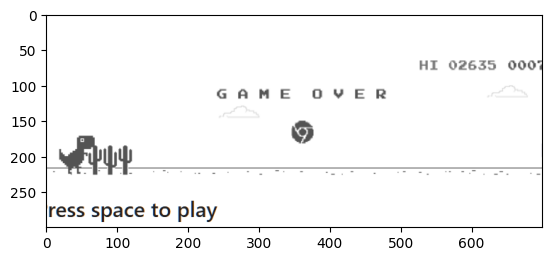

In [11]:
time.sleep(1)

dino_env=DinoEnv(monitor,game_over_monitor)
time.sleep(1)
state, info = dino_env.reset()
done = False
while not done:
    state, reward, done, _ , info = dino_env.step(0)  
plt.imshow(dino_env.render());

# 3 Data Proprocessing

now we can apply the following transformations

1.  Grayscale
2.  Resize
3.  Frame Stacking

**1.  Grayscale**

In [8]:
from gymnasium.wrappers import GrayscaleObservation, ResizeObservation, FrameStackObservation

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


inside _init_game()
Chrome has succesfully opened


d:\classical_dino_game_rl\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


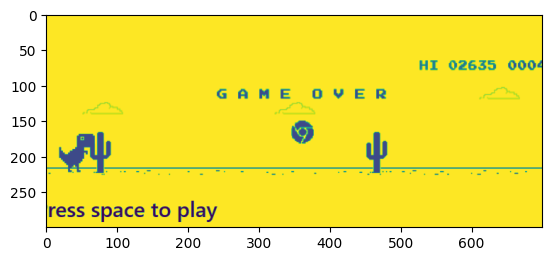

In [13]:
dino_env=DinoEnv(monitor,game_over_monitor)
time.sleep(1)
dino_env = GrayscaleObservation(dino_env, keep_dim=False)
state, info = dino_env.reset()
done = False
while not done:
    state, reward, done, _ , info = dino_env.step(0)  
plt.imshow(state);

**2.  Resize**


In [ ]:
300, 700

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


inside _init_game()
Chrome has succesfully opened


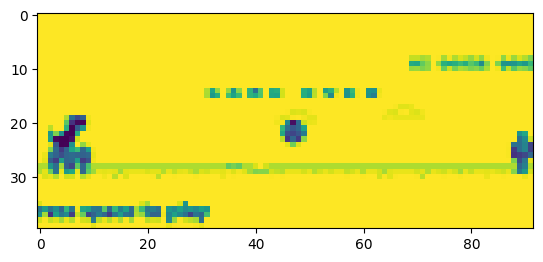

In [22]:
dino_env = DinoEnv(monitor,game_over_monitor)
dino_env = GrayscaleObservation(dino_env, keep_dim=False)
dino_env = ResizeObservation(dino_env, shape=(40,92))
time.sleep(1)

state, info = dino_env.reset()
done = False
while not done:
    state, reward, done, _ , info = dino_env.step(0)  
plt.imshow(state);